In [1]:
import pandas as pd
data=pd.read_csv('data_clean.csv')

In [2]:
data1=data

In [3]:
data.head()

,Unnamed: 0,Ozone,Solar.R,Wind,Temp C,Month,Day,Year,Temp,Weather
0,1,41.0,190.0,7.4,67,5,1,2010,67,S
1,2,36.0,118.0,8.0,72,5,2,2010,72,C
2,3,12.0,149.0,12.6,74,5,3,2010,74,PS
3,4,18.0,313.0,11.5,62,5,4,2010,62,S
4,5,NaN,NaN,14.3,56,5,5,2010,56,S


In [4]:
data=data.drop('Unnamed: 0',axis=1)

In [5]:
data=data.drop('Temp C',axis=1)

In [6]:
data.head()

,Ozone,Solar.R,Wind,Month,Day,Year,Temp,Weather
0,41.0,190.0,7.4,5,1,2010,67,S
1,36.0,118.0,8.0,5,2,2010,72,C
2,12.0,149.0,12.6,5,3,2010,74,PS
3,18.0,313.0,11.5,5,4,2010,62,S
4,NaN,NaN,14.3,5,5,2010,56,S


In [7]:
data=data.rename({'Solar.R':'Solar'},axis=1)
data.head()

,Ozone,Solar,Wind,Month,Day,Year,Temp,Weather
0,41.0,190.0,7.4,5,1,2010,67,S
1,36.0,118.0,8.0,5,2,2010,72,C
2,12.0,149.0,12.6,5,3,2010,74,PS
3,18.0,313.0,11.5,5,4,2010,62,S
4,NaN,NaN,14.3,5,5,2010,56,S


In [8]:
data.shape

(158, 8)

In [9]:
data.columns.tolist()

['Ozone', 'Solar', 'Wind', 'Month', 'Day', 'Year', 'Temp', 'Weather']

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158 entries, 0 to 157
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Ozone    120 non-null    float64
 1   Solar    151 non-null    float64
 2   Wind     158 non-null    float64
 3   Month    158 non-null    object 
 4   Day      158 non-null    int64  
 5   Year     158 non-null    int64  
 6   Temp     158 non-null    int64  
 7   Weather  155 non-null    object 
dtypes: float64(3), int64(3), object(2)
memory usage: 10.0+ KB


In [11]:
data[data.duplicated()].shape

(1, 8)

In [12]:
print(data[data.duplicated()])

     Ozone  Solar  Wind Month  Day  Year  Temp Weather
156   14.0  191.0  14.3     9   28  2010    75       S


In [13]:
data=data.drop_duplicates()

In [14]:
#changing of categories to numeric or vice versa
data[data['Month'].isna()]

,Ozone,Solar,Wind,Month,Day,Year,Temp,Weather


In [15]:
data['Month'] = data['Month'].replace({'January': 1,'February': 2,'March': 3,'April': 4,'May': 5,'June': 6,'July': 7,'August': 8,'September': 9,'October': 10,'November': 11,
                                       'December': 12})

In [16]:
data[pd.to_numeric(data['Month'], errors='coerce').isna()]

,Ozone,Solar,Wind,Month,Day,Year,Temp,Weather


In [17]:
data[data['Weather'].isna()]

,Ozone,Solar,Wind,Month,Day,Year,Temp,Weather
87,52.0,82.0,12.0,7,27,2010,86,NaN
93,9.0,24.0,13.8,8,2,2010,81,NaN
95,78.0,NaN,6.9,8,4,2010,86,NaN


In [18]:
data['Weather']=data['Weather'].astype('category')

In [19]:
data[data['Weather'].isna()]

,Ozone,Solar,Wind,Month,Day,Year,Temp,Weather
87,52.0,82.0,12.0,7,27,2010,86,NaN
93,9.0,24.0,13.8,8,2,2010,81,NaN
95,78.0,NaN,6.9,8,4,2010,86,NaN


In [20]:
data[data['Temp'].isna()]

,Ozone,Solar,Wind,Month,Day,Year,Temp,Weather


In [21]:
data.isnull().sum()

Ozone      38
Solar       7
Wind        0
Month       0
Day         0
Year        0
Temp        0
Weather     3
dtype: int64

In [22]:
data[data['Solar'].isna()]

,Ozone,Solar,Wind,Month,Day,Year,Temp,Weather
4,NaN,NaN,14.3,5,5,2010,56,S
5,28.0,NaN,14.9,5,6,2010,66,C
10,7.0,NaN,6.9,5,11,2010,74,C
26,NaN,NaN,8.0,5,27,2010,57,PS
95,78.0,NaN,6.9,8,4,2010,86,NaN
96,35.0,NaN,7.4,8,5,2010,85,S
97,66.0,NaN,4.6,8,6,2010,87,C


In [23]:
m=data['Ozone'].mean()
data['Ozone']=data['Ozone'].fillna(m)

In [24]:
data.isnull().sum()

Ozone      0
Solar      7
Wind       0
Month      0
Day        0
Year       0
Temp       0
Weather    3
dtype: int64

In [25]:
n=data['Solar'].mean()
data['Solar']=data['Solar'].fillna(n)

In [26]:
data.isnull().sum()

Ozone      0
Solar      0
Wind       0
Month      0
Day        0
Year       0
Temp       0
Weather    3
dtype: int64

In [27]:
o=data['Weather'].mode()[0]
data['Weather']=data['Weather'].fillna(o)

In [28]:
data.isnull().sum()

Ozone      0
Solar      0
Wind       0
Month      0
Day        0
Year       0
Temp       0
Weather    0
dtype: int64

# Outlier detection

{'whiskers': [<matplotlib.lines.Line2D at 0x10c4c02d0>,
 'caps': [<matplotlib.lines.Line2D at 0x10c4c0550>,
 'boxes': [<matplotlib.lines.Line2D at 0x10c3a4050>],
 'medians': [<matplotlib.lines.Line2D at 0x10c3a5a90>],
 'fliers': [<matplotlib.lines.Line2D at 0x10c4c07d0>],
 'means': []}

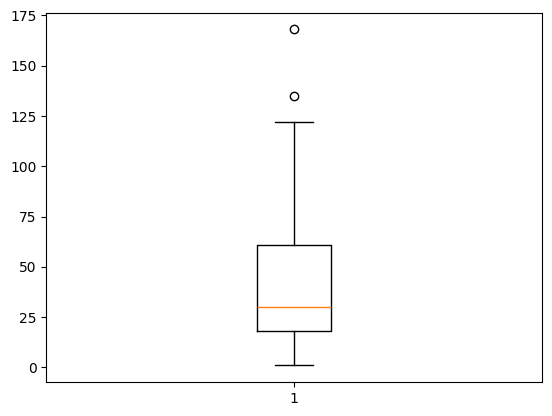

In [29]:
import matplotlib.pyplot as plt
data_box=data1.dropna()
data2_box=data_box.Ozone
plt.boxplot(data2_box)

In [30]:
#coorelartion
data.corr(numeric_only=True)

,Ozone,Solar,Wind,Day,Year,Temp
Ozone,1.000000,0.304559,-0.520004,-0.021916,NaN,0.606500
Solar,0.304559,1.000000,-0.055874,-0.151007,NaN,0.260677
Wind,-0.520004,-0.055874,1.000000,0.029900,NaN,-0.441228
Day,-0.021916,-0.151007,0.029900,1.000000,NaN,-0.122787
Year,NaN,NaN,NaN,NaN,NaN,NaN
Temp,0.606500,0.260677,-0.441228,-0.122787,NaN,1.000000


In [31]:
#Dummies
data2=pd.get_dummies(data,columns=['Weather']).astype(int)

In [32]:
data2

,Ozone,Solar,Wind,Month,Day,Year,Temp,Weather_C,Weather_PS,Weather_S
0,41,190,7,5,1,2010,67,0,0,1
1,36,118,8,5,2,2010,72,1,0,0
2,12,149,12,5,3,2010,74,0,1,0
3,18,313,11,5,4,2010,62,0,0,1
4,41,185,14,5,5,2010,56,0,0,1
...,...,...,...,...,...,...,...,...,...,...
152,20,223,11,9,30,2010,68,0,0,1
153,41,190,7,5,1,2010,67,1,0,0
154,30,193,6,9,26,2010,70,0,1,0
155,41,145,13,9,27,2010,77,0,0,1


In [40]:
from numpy import set_printoptions
from sklearn.preprocessing import MinMaxScaler

array = data2.values

scaler = MinMaxScaler(feature_range=(0,1))
scalerxd = scaler.fit_transform(array)

set_printoptions(precision=2)

print(scalerxd[0:5,:])

[[0.24 0.56 0.32 0.   0.   0.   0.27 0.   0.   1.  ]
 [0.21 0.34 0.37 0.   0.03 0.   0.39 1.   0.   0.  ]
 [0.07 0.43 0.58 0.   0.07 0.   0.44 0.   1.   0.  ]
 [0.1  0.94 0.53 0.   0.1  0.   0.15 0.   0.   1.  ]
 [0.24 0.54 0.68 0.   0.13 0.   0.   0.   0.   1.  ]]


In [41]:
#merging 2 files
salary1=pd.read_csv('basic_salary.csv')
salary2=pd.read_csv('basic_salary_2.csv')

In [42]:
Frames=[salary1,salary2]
data_merge=pd.concat(Frames)

In [43]:
print(data_merge)

  First_Name Last_Name Grade Location     ba       ms
0       Alan     Brown   GR1    DELHI  17990  16070.0
1     Agatha  Williams   GR2   MUMBAI  12390   6630.0
2     Rajesh     Kolte   GR1   MUMBAI  19250  14960.0
3      Ameet    Mishra   GR2    DELHI  14780   9300.0
4       Neha       Rao   GR1   MUMBAI  19235  15200.0
0      Sagar    Chavan   GR2   MUMBAI  13390   6700.0
1      Aaron     Jones   GR1   MUMBAI  23280  13490.0
2       John     Patil   GR2   MUMBAI  13500  10760.0
3      Sneha     Joshi   GR1    DELHI  20660      NaN
4     Gaurav     Singh   GR2    DELHI  13760  13220.0
5      Adela    Thomas   GR2    DELHI  13660   6840.0
6       Anup      Save   GR2   MUMBAI  11960   7880.0
